In [74]:
import sklearn
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler, OneHotEncoder



In [75]:
df_obras = pd.read_csv('../../db/clean/df_cluster.csv')


In [76]:
df_obras.head()


,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical
0,False,False,False,2281.0,1.0,1.0,21229.39,True,False,True,False,False,False,True,False,False
1,False,False,False,353.0,1.0,1.0,1788.50,True,False,True,False,False,False,True,False,False
2,False,False,True,23017.0,15.0,15.0,86320.45,True,False,True,False,False,False,True,False,False
3,False,False,True,16125.0,14.0,14.0,143806.29,True,False,True,False,False,False,True,False,False
4,False,False,False,67061.0,916.0,122.0,1001282.58,True,False,True,False,False,False,True,False,False


In [77]:
df_obras['renda_total'].max

<bound method Series.max of 0          21229.39
1           1788.50
2          86320.45
3         143806.29
4        1001282.58
           ...     
1736     1399974.44
1737        6997.05
1738      276329.35
1739    15621834.49
1740        7925.15
Name: renda_total, Length: 1741, dtype: float64>

In [78]:
#scaler = StandardScaler()
#df_obras['renda_total'] = scaler.fit_transform(df_obras[['renda_total']])
#df_obras['publico_total'] = scaler.fit_transform(df_obras[['publico_total']])
#df_obras['qtd_sessoes'] = scaler.fit_transform(df_obras[['qtd_sessoes']])
#df_obras['dias_cartaz'] = scaler.fit_transform(df_obras[['dias_cartaz']])


In [79]:
#seleciona as colunas pra ir pros clusters
#df_obras= df_obras1[['tipo_obra']]

In [80]:
obras = df_obras

# Método do cotovelo

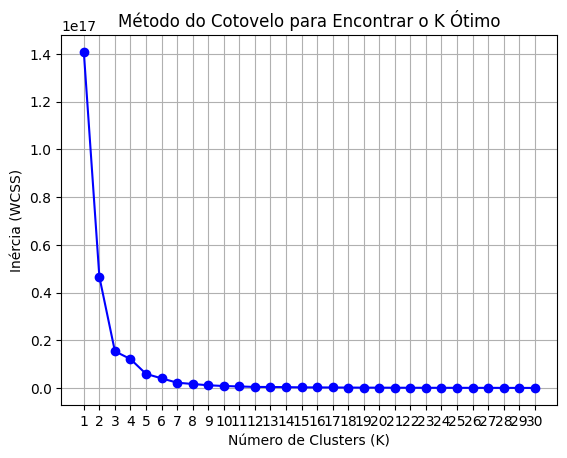

In [81]:
# Implementando o Método do Cotovelo com visualização iterativa
k_range = range(1, 31)
inertias = []
clustering_results = []

for k in k_range:
    model = KMeans(n_clusters=k, max_iter=150, random_state=42)
    model.fit(obras)

    inertias.append(model.inertia_)
    clustering_results.append({'labels': model.labels_, 'centroids': model.cluster_centers_})

# Plotar o gráfico do cotovelo
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.title('Método do Cotovelo para Encontrar o K Ótimo')
plt.xticks(k_range)
plt.grid(True)
plt.show()

<Axes: xlabel='publico_total', ylabel='dias_cartaz'>

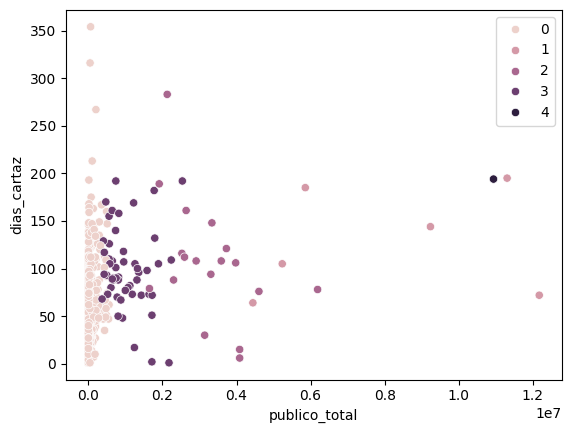

In [ ]:
#clusterização com o K-Means
kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(obras)
clusters_kmeans = kmeans.predict(obras)
obras['cluster_kmeans'] = clusters_kmeans
sns.scatterplot(data=obras, x='publico_total',y= 'dias_cartaz', hue=clusters_kmeans)

- tentamos com titulo original e deu erro
- tentamos com tipo de obra e nao encontramos semelhança
- com classificacao obra e nao encontramos similaridade entre pontos do mesmo cluster
- tentamos com duracao total em minutos e vemos que ele separou relativamente bem curtas e longa metragem

# Usando t-SNE para melhor visualização em duas dimensões

In [83]:
#reduz a dimensionalidade para observar melhor
tsne_obras = TSNE(n_components=2, init="random").fit_transform(obras)

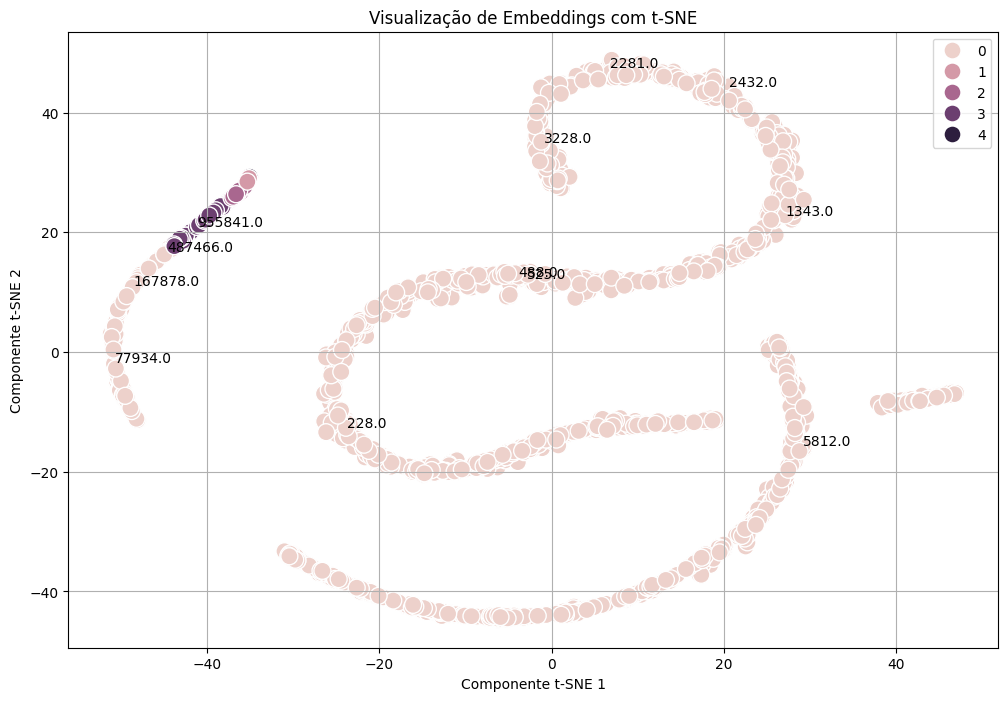

In [84]:
# Cria um DataFrame para a plotagem
df_tsne = pd.DataFrame({
    'x': tsne_obras[:, 0],
    'y': tsne_obras[:, 1],
    'titles': df_obras['publico_total'],
})

# Plota os resultados
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_tsne, x='x', y='y', s=150, hue=clusters_kmeans)

# Adiciona anotações aos pontos
for i in range(0, df_tsne.shape[0], 150):
    plt.text(
        df_tsne.x[i],
        df_tsne.y[i],
        df_tsne.titles[i],
        ha='left',
        size=10,
        color='black',
        alpha=1.0,
        weight='normal'
    )

plt.title('Visualização de Embeddings com t-SNE')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.grid(True)
plt.show()

# Utilizando PCA

In [85]:
pca_obras = PCA(n_components=2).fit_transform(obras)

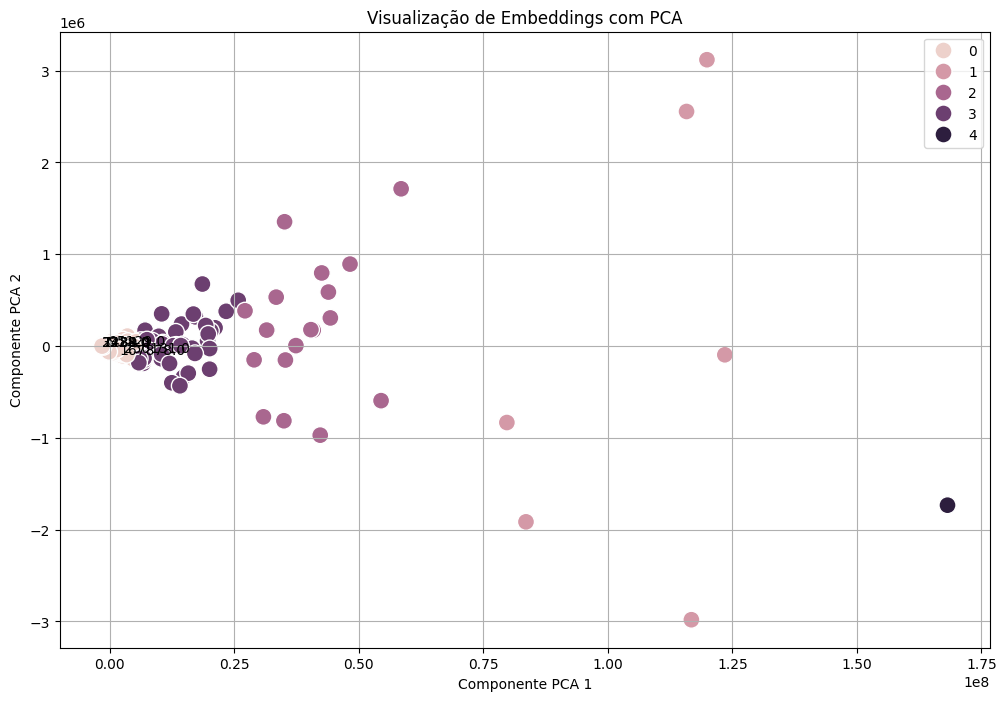

In [86]:
# Cria um DataFrame para a plotagem
df_pca = pd.DataFrame({
    'x': pca_obras[:, 0],
    'y': pca_obras[:, 1],
    'titles': df_obras['publico_total'],
})

# Plota os resultados
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_pca, x='x', y='y', s=150, hue=clusters_kmeans)

# Adiciona anotações aos pontos
for i in range(0, df_pca.shape[0], 250):
    plt.text(
        df_pca.x[i],
        df_pca.y[i],
        df_pca.titles[i],
        ha='left',
        size=10,
        color='black',
        alpha=1.0,
        weight='normal'
    )

plt.title('Visualização de Embeddings com PCA')
plt.xlabel('Componente PCA 1')
plt.ylabel('Componente PCA 2')
plt.grid(True)
plt.show()

Conseguimos observar uma aglomeração de alguns estilos como ficção e animação?

cremos que por ser uma base de dados com muito ruído o DBSCAN apresentaria melhor desempenho.

# Utilizando o DBSCAN

In [87]:
#padrão scikitlearn:(eps=0.5, *, min_samples=5, metric='euclidean', metric_params=None, algorithm='auto', leaf_size=30, p=None, n_jobs=None)
#através de testes arbitrários de 0.5 a 3.5
#1000000, 1386
dbscan = DBSCAN(eps=3, min_samples=2, metric='euclidean')
clusters_DBSCAN = dbscan.fit_predict(tsne_obras)

# Com t_SNE

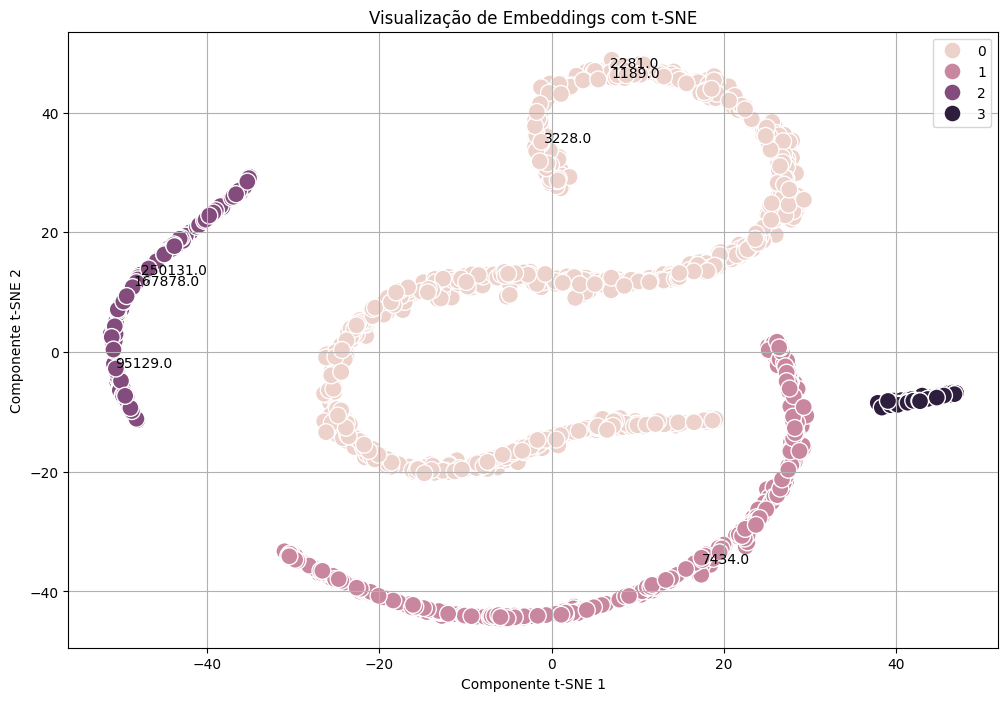

In [88]:
# Cria um DataFrame para a plotagem
df_tsne = pd.DataFrame({
    'x': tsne_obras[:, 0],
    'y': tsne_obras[:, 1],
    'titles': df_obras['publico_total'],
})

# Plota os resultados
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_tsne, x='x', y='y', s=150, hue=clusters_DBSCAN)

# Adiciona anotações aos pontos
for i in range(0, df_tsne.shape[0], 250):
    plt.text(
        df_tsne.x[i],
        df_tsne.y[i],
        df_tsne.titles[i],
        ha='left',
        size=10,
        color='black',
        alpha=1.0,
        weight='normal'
    )

plt.title('Visualização de Embeddings com t-SNE')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.grid(True)
plt.show()

## podemos observar pelo texto indicando o publico total que o criterio de separação tem relação com o publico total.

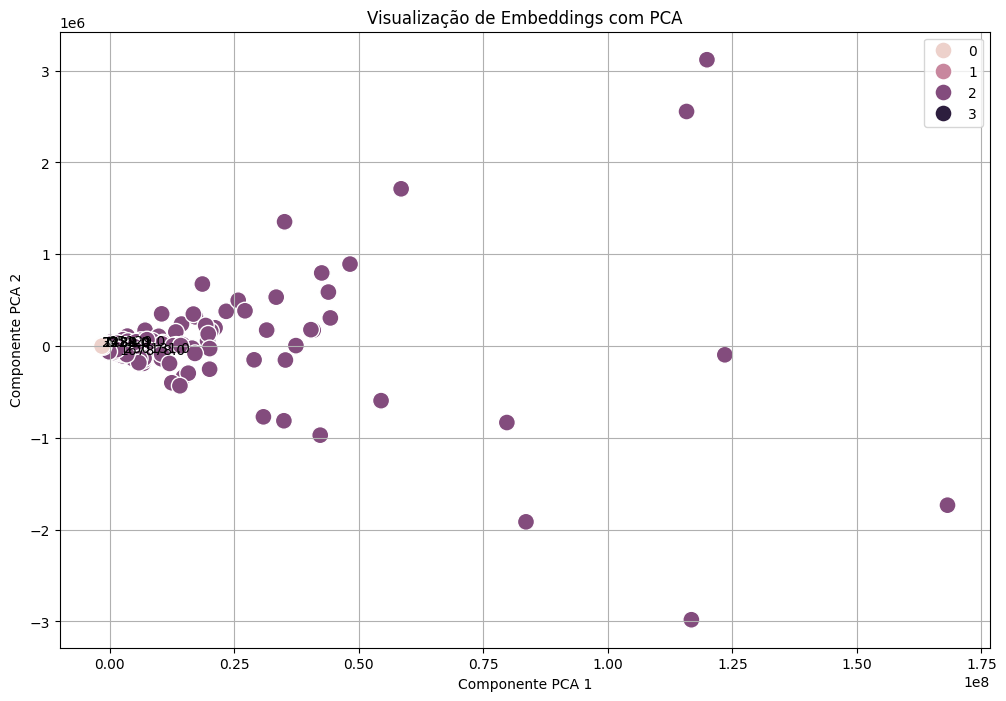

In [89]:
df_pca# Cria um DataFrame para a plotagem
df_pca = pd.DataFrame({
    'x': pca_obras[:, 0],
    'y': pca_obras[:, 1],
    'titles': df_obras['publico_total'],
})

# Plota os resultados
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_pca, x='x', y='y', s=150, hue=clusters_DBSCAN)

# Adiciona anotações aos pontos
for i in range(0, df_pca.shape[0], 250):
    plt.text(
        df_pca.x[i],
        df_pca.y[i],
        df_pca.titles[i],
        ha='left',
        size=10,
        color='black',
        alpha=1.0,
        weight='normal'
    )

plt.title('Visualização de Embeddings com PCA')
plt.xlabel('Componente PCA 1')
plt.ylabel('Componente PCA 2')
plt.grid(True)
plt.show()

In [90]:
clustering = AgglomerativeClustering().fit(obras)


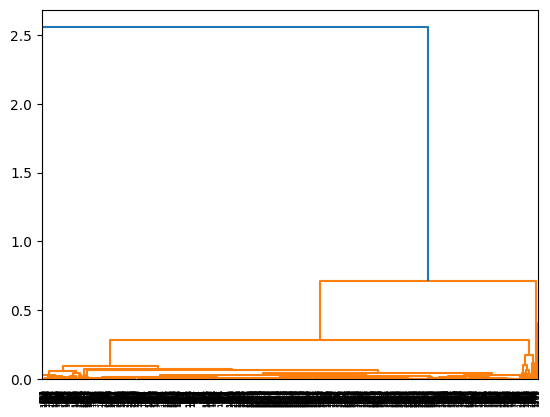

In [91]:
# obtendo medida de distância baseada no cosseno
similarity_distance = 1 - cosine_similarity(obras)

# computa a sequência de grupos unidos usando a ligação média
mergings = linkage(similarity_distance, method='average')

# configura o dendrograma
dendrogram_ = dendrogram(mergings,
               leaf_rotation=90
)

### sabemos que o melhor número de clusters é 5, pelo método do cotovelo aplicado acima

## observando os pontos nos centros de cada cluster

In [92]:
#
km = KMeans(n_clusters=5, random_state=8)
km.fit(obras)
centers = km.cluster_centers_
centroids = pd.DataFrame(centers.round().astype(int))
centroids.columns = obras.keys().values
centroids.head()

,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical,cluster_kmeans
0,0,0,0,18966,613,38,271927,1,0,1,0,0,0,1,0,0,0
1,0,0,1,4838508,33791,84,83065147,1,0,1,0,0,0,1,0,0,1
2,0,0,1,1044335,11250,99,13780920,1,0,1,0,0,0,1,0,0,3
3,0,0,0,9902008,33309,158,130003803,1,0,1,0,0,0,1,0,0,2
4,0,0,1,3261547,16192,107,40864616,1,0,1,0,0,0,1,0,0,2


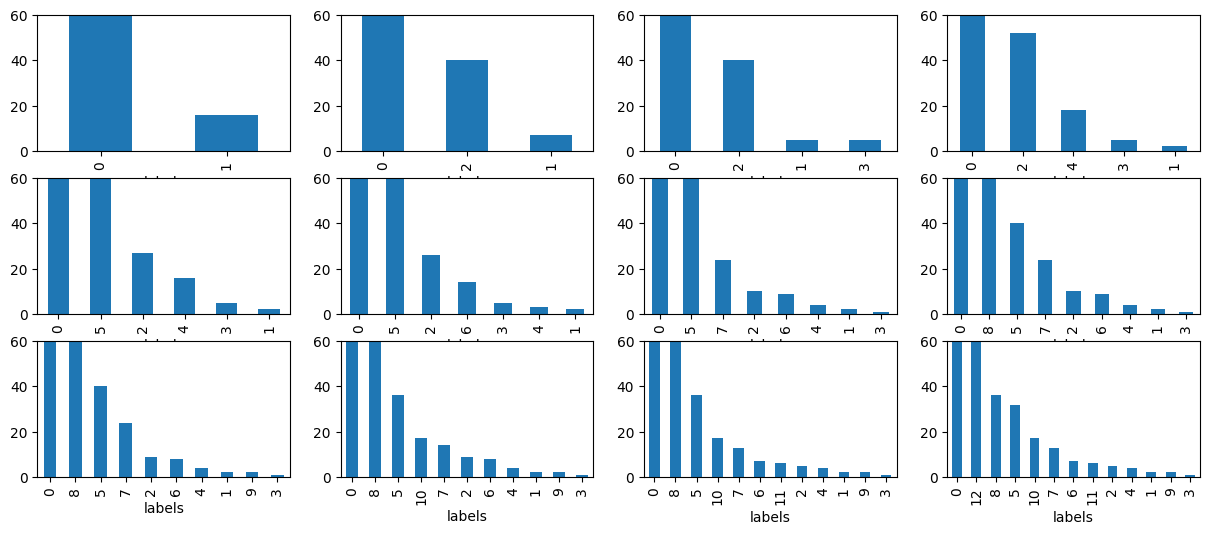

In [93]:
# configuração do gráfico que vai ser gerado
fig, axs = plt.subplots(3,4, figsize=(15, 6), facecolor='w', edgecolor='k')
axs = axs.ravel()

# dataframe para armazenar os dados
df = pd.DataFrame()

# intervalo com a quantidade de grupos que vamos dividir os dados
ks = range(2, 14)
for k in ks:
  # executa o kmeans para cada quantidade de grupos
  km = KMeans(n_clusters=k, random_state=8, n_init='auto')
  # relaciona o resultado gerado com os dados da base
  km.fit(obras)
  # resgata os rótulos (grupos) para cada objeto da base
  labels = km.labels_.tolist()
  # cria um dataframe para facilitar a contagem dos objetos em cada grupo
  df['labels'] = labels
  # plota a quantidade de objetos em cada grupo
  df['labels'].value_counts().plot(kind='bar',ax=axs[k-2],ylim=(0,60))

## Onservar os pontos no cluster 2

In [94]:
obras[km.labels_ == 2]

,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical,cluster_kmeans
219,False,False,True,2237776.0,11463.0,109.0,24827669.51,True,False,True,False,False,False,True,False,False,3
307,False,False,True,2537628.0,22181.0,192.0,27221239.28,True,False,True,False,False,False,True,False,False,3
420,False,False,True,2525347.0,22271.0,116.0,28590845.61,True,False,True,False,False,False,True,False,False,2
1078,True,False,True,2129138.0,21874.0,283.0,30453059.16,True,False,True,False,False,False,True,False,False,2
1513,False,False,True,1649559.0,24775.0,79.0,32366041.76,True,False,True,False,False,False,True,False,False,2


### para fins de exemplo vamos mostrar como seria com mais grupos

In [95]:
ks = range(6, 10)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10)
    km.fit(obras)
    centers = km.cluster_centers_
    centroids = pd.DataFrame(centers.round().astype(int))
    centroids.columns = obras.keys().values
    display(centroids)

,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical,cluster_kmeans
0,0,0,0,15630,561,38,225503,1,0,1,0,0,0,1,0,0,0
1,0,0,0,9642950,31472,149,120154596,0,0,1,0,0,0,1,0,0,1
2,0,0,1,2983660,15379,113,37330826,1,0,1,0,0,0,1,0,0,2
3,0,0,1,4863599,28963,89,70446852,1,0,1,0,0,0,1,0,0,2
4,0,0,1,891423,10408,96,12008302,1,0,1,0,0,0,1,0,0,2
5,0,0,1,10938240,40659,194,169400632,1,0,1,0,0,0,1,0,0,4


,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical,cluster_kmeans
0,0,0,0,11363,471,37,164831,1,0,1,0,0,0,1,0,0,0
1,0,0,1,4838508,33791,84,83065147,1,0,1,0,0,0,1,0,0,1
2,0,0,1,3378336,15457,95,42282448,1,0,1,0,0,0,1,0,0,2
3,0,0,0,9642950,31472,149,120154596,0,0,1,0,0,0,1,0,0,1
4,0,0,1,1511746,13824,104,19391420,1,0,1,0,0,0,1,0,0,3
5,1,0,1,503094,8202,90,7033241,1,0,1,0,0,0,1,0,0,1
6,0,0,1,10938240,40659,194,169400632,1,0,1,0,0,0,1,0,0,4


,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical,cluster_kmeans
0,0,0,0,11363,471,37,164831,1,0,1,0,0,0,1,0,0,0
1,0,0,1,4838508,33791,84,83065147,1,0,1,0,0,0,1,0,0,1
2,0,0,1,1401043,12789,93,18220966,1,0,1,0,0,0,1,0,0,3
3,0,0,0,9642950,31471,149,120154596,0,0,1,0,0,0,1,0,0,1
4,1,0,1,503094,8202,90,7033241,1,0,1,0,0,0,1,0,0,1
5,0,0,1,3902023,15649,92,47548686,1,0,1,0,0,0,1,0,0,2
6,0,0,1,10938240,40659,194,169400632,1,0,1,0,0,0,1,0,0,4
7,0,0,1,2612728,17280,128,33484614,1,0,1,0,0,0,1,0,0,2


,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical,cluster_kmeans
0,1,0,1,200229,5148,78,2921140,1,0,1,0,0,0,1,0,0,0
1,0,0,1,4838508,33791,84,83065147,1,0,1,0,0,0,1,0,0,1
2,0,0,1,2612728,17280,128,33484614,1,0,1,0,0,0,1,0,0,2
3,0,0,0,9642950,31471,149,120154596,0,0,1,0,0,0,1,0,0,1
4,1,0,1,607994,8893,97,8444451,1,0,1,0,0,0,1,0,0,2
5,0,0,1,3902023,15649,92,47548686,1,0,1,0,0,0,1,0,0,2
6,0,0,1,10938240,40659,194,169400632,1,0,1,0,0,0,1,0,0,4
7,0,0,1,1401043,12789,93,18220966,1,0,1,0,0,0,1,0,0,3
8,0,0,0,6577,339,36,93723,1,0,1,0,0,0,1,0,0,0


In [100]:
# Crie um DataFrame de médias para a descrição
cluster_medians = obras.groupby('cluster_kmeans').median()

# Exiba as médias para identificar as características únicas de cada cluster (Cluster 0, Cluster 1, etc.)
display(cluster_medians)

,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical
cluster_kmeans,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,1373.5,119.5,30.0,1.701935e+04,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.5,7546547.0,25820.0,124.5,1.175246e+08,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,3224304.0,16814.0,107.0,4.030921e+07,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,850455.0,9875.0,93.5,1.210434e+07,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,10938240.0,40659.0,194.0,1.694006e+08,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
